In [1]:
# Transformers installation
! pip install transformers datasets evaluate accelerate
# To install from source instead of the last release, comment the command above and uncomment the following one.
! pip install git+https://github.com/huggingface/transformers.git

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 8.5 MB/s eta 0:00:00
  Cloning https://github.com/huggingface/transformers.git to /tmp/pip-req-build-_lynhcox
  Running command git clone --filter=blob:none --quiet https://github.com/huggingface/transformers.git /tmp/pip-req-build-_lynhcox
  Resolved https://github.com/huggingface/transformers.git to commit 031cfc589b66af52d7c14a5d141deb0ca6a0e6f1
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 798.3/798.3 kB 24.6 MB/s eta 0:00:00
  Created wheel for transformers: filename=transformers-5.18.0.dev0-py3-none-any.whl size=13589094 sha256=df744ba86314277c22f91f38149d8d12f1094631d285ca10a3e8d754948c9149
  Stored in directory: /tmp/pip-ephem-wheel-cache-yts34e8c/wheels/90/86/bb/8ad35b428289429952d8316d30f64abedae0ab2fcee0f4f46f
Successfully built transformers
  Attempting uninstall: huggingface-hub
    Fou

# Image-text-to-text

Image-text-to-text models, also known as vision language models (VLMs), are language models that take an image input. These models can tackle various tasks, from visual question answering to image segmentation. This task shares many similarities with image-to-text, but with some overlapping use cases like image captioning. Image-to-text models only take image inputs and often accomplish a specific task, whereas VLMs take open-ended text and image inputs and are more generalist models.

In this guide, we provide a brief overview of VLMs and show how to use them with Transformers for inference.

To begin with, there are multiple types of VLMs:

- base models used for fine-tuning
- chat fine-tuned models for conversation
- instruction fine-tuned models

This guide focuses on inference with an instruction-tuned model.

Let's begin installing the dependencies.

```bash
pip install -q transformers accelerate
pip install flash-attn --no-build-isolation
```

Let's initialize the model and the processor.

In [2]:
from transformers import AutoProcessor, AutoModelForImageTextToText
from accelerate import Accelerator
import torch

device = Accelerator().device
model = AutoModelForImageTextToText.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct",
    dtype=torch.bfloat16,
    attn_implementation="flash_attention_2",
).to(device)

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-4B-Instruct")

config.json:   0%|          | 0.00/1.50k [00:00<?, ?B/s]

model.safetensors.index.json:   0%|          | 0.00/64.7k [00:00<?, ?B/s]

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

ImportError: FlashAttention2 has been toggled on, but it cannot be used due to the following error: the package for FlashAttention2 doesn't seem to be installed.

In [5]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct",
    dtype=torch.float16,
    device_map="auto",
    attn_implementation="sdpa",
)

processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct"
)

print("Model loaded successfully!")

Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/269 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/390 [00:00<?, ?B/s]

...

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

video_preprocessor_config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

Model loaded successfully!


This model has a [chat template](https://huggingface.co/docs/transformers/main/en/tasks/../chat_templating) that helps user parse chat outputs. Moreover, the model can also accept multiple images as input in a single conversation or message. We will now prepare the inputs.

The image inputs look like the following.

<div class="flex justify-center">
     <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/cats.png" alt="Two cats sitting on a net"/>
</div>

<div class="flex justify-center">
     <img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/bee.jpg" alt="A bee on a pink flower"/>
</div>

Structure your conversation as shown below for a single prompt with image and text inputs.

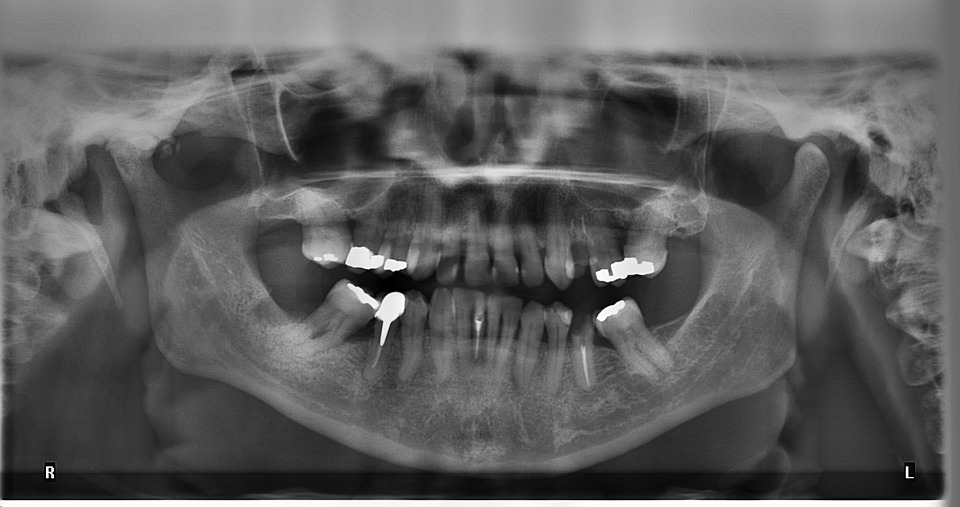

In [30]:
from PIL import Image
from IPython.display import display

image_path = "/content/tooth-1462410_960_720.jpeg"

image = Image.open(image_path)

display(image)

In [21]:
messages = [
    {
        "role": "user",
        "content": [
            {"type": "image", "image": "/content/tooth-1462410_960_720.jpeg"},
            {"type": "text", "text": "What do we see in this image?"},
        ]
    }
]

Alternate between the `user` and `assistant` role to ground the model with prior context to generate better responses.

In [27]:
messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "/content/tooth-1462410_960_720.jpeg",
                "min_pixels": 512 * 512,
                "max_pixels": 1024 * 1024,
            },
            {
                "type": "text",
                "text": """
Carefully inspect this dental radiograph.

First identify the radiograph type and describe the teeth and anatomical
structures that are actually visible.

Then systematically inspect the image for:

- dental caries
- fractured or broken teeth
- missing teeth
- impacted or unerupted teeth
- retained roots
- root fractures or abnormal root morphology
- root resorption
- periapical radiolucencies or lesions
- signs suggestive of periapical infection
- root canal treatment
- abnormal or incomplete root canal treatment
- periodontal bone loss
- horizontal bone loss
- vertical bone loss
- furcation involvement
- crowns
- fillings and restorations
- defective restorations
- bridges
- implants
- peri-implant bone loss
- posts and cores
- extraction sites
- radiolucent jaw lesions
- radiopaque jaw lesions
- mixed bone lesions
- abnormal bone density
- maxillary sinus abnormalities
- mandibular abnormalities
- abnormal tooth position
- crowding
- supernumerary teeth
- signs of trauma
- any other visible dental or maxillofacial finding

IMPORTANT INSTRUCTIONS:

1. Examine the image itself and report visible observations.
2. Do not simply answer "cannot be assessed" for every category.
3. If no abnormality is seen in a category, write "No obvious abnormality detected."
4. Use "Cannot be reliably assessed" only when image quality or projection
   genuinely prevents evaluation.
5. Do not invent abnormalities.
6. Distinguish direct visual observations from possible interpretations.
7. Mention the FDI tooth number when reasonably identifiable.
8. For each abnormal finding give:
   - tooth/location
   - visible finding
   - confidence: High / Moderate / Low

Return the report in this format:

IMAGE TYPE:
...

IMAGE QUALITY:
...

DENTITION OVERVIEW:
...

CARIES:
...

FRACTURED / DAMAGED TEETH:
...

MISSING TEETH:
...

IMPACTED / UNERUPTED TEETH:
...

ROOT FINDINGS:
...

PERIAPICAL FINDINGS:
...

ENDODONTIC FINDINGS:
...

PERIODONTAL / BONE FINDINGS:
...

RESTORATIONS / CROWNS / BRIDGES:
...

IMPLANTS:
...

JAW / BONE FINDINGS:
...

MAXILLARY SINUSES:
...

OTHER FINDINGS:
...

SUMMARY OF ABNORMAL FINDINGS:
...

POSSIBLE INTERPRETATION:
...

Do not provide a definitive clinical diagnosis. This is radiographic
image analysis only.
"""
            },
        ],
    }
]

We will now call the processors' [apply_chat_template()](https://huggingface.co/docs/transformers/main/en/main_classes/processors#transformers.ProcessorMixin.apply_chat_template) method to preprocess its output along with the image inputs.

In [28]:
inputs = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=True, return_dict=True, return_tensors="pt").to(device)

We can now pass the preprocessed inputs to the model.

In [29]:
input_len = len(inputs.input_ids[0])

with torch.no_grad():
    generated_ids = model.generate(**inputs, max_new_tokens=1000)
generated_texts = processor.batch_decode(generated_ids[:, input_len:], skip_special_tokens=True)

print(generated_texts)
## ['In this image we can see flowers, plants and insect.']

['IMAGE TYPE:\nPanoramic radiograph (also known as an OPG or orthopantomogram).\n\nIMAGE QUALITY:\nModerate. The image is somewhat blurry and has low contrast, particularly in the midline and soft tissue regions. The bony structures are visible, but fine details (e.g., root canal morphology, small periapical lesions) are not clearly distinguishable. The radiograph is oriented with “R” on the left and “L” on the right, indicating the patient’s right side is on the left of the image.\n\nDENTITION OVERVIEW:\nThe image shows the full dentition of both the maxilla and mandible, including anterior, premolar, and molar teeth. The mandibular arch is more prominently visible. The maxillary arch is partially visible. Several teeth have restorations (crowns or fillings) visible as radiopaque structures. The mandibular first molars and premolars appear to have root canals treated, as indicated by the presence of posts or cores. The patient appears to have some missing teeth, particularly in the ma

IMAGE:


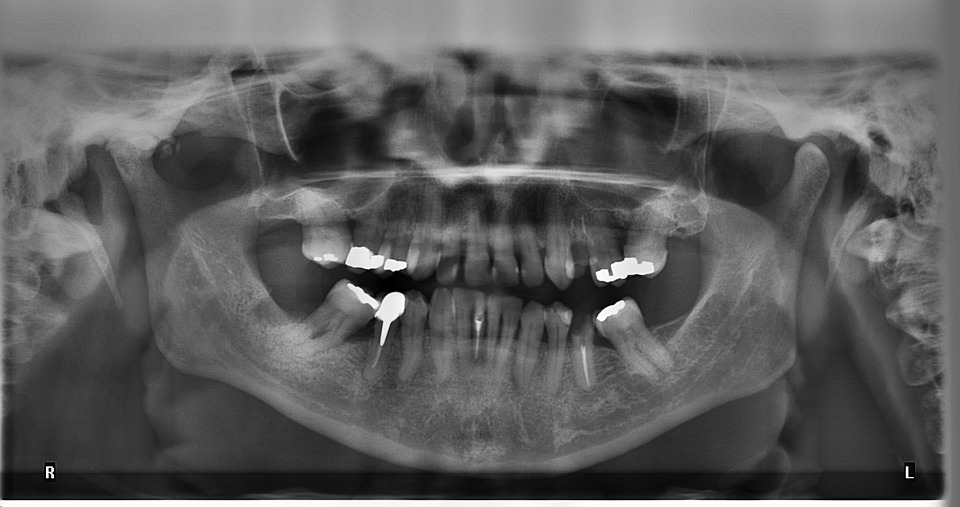


MODEL OUTPUT:

IMAGE TYPE:
Panoramic radiograph (also known as an OPG or orthopantomogram).

IMAGE QUALITY:
Moderate. The image is somewhat blurry and has low contrast, particularly in the central region where the teeth are most densely packed. The edges of some teeth and bony structures are not sharply defined. The “R” and “L” markers are visible, indicating the image is oriented with R on the left and L on the right (standard for panoramic radiographs). The image appears to be taken with adequate exposure, but resolution is limited.

DENTITION OVERVIEW:
The radiograph shows the full dentition of both the maxilla and mandible, including anterior, premolar, and molar teeth. The mandibular arch is more clearly visible due to the projection. Several teeth have restorations (fillings or crowns) visible as radiopaque structures. The mandibular molars and premolars appear to have some crowns or posts. The maxillary molars are partially visible. The image is not fully focused, making some t

In [32]:
from PIL import Image
from IPython.display import display
import torch

# Generate model output
input_len = len(inputs.input_ids[0])

with torch.no_grad():
    generated_ids = model.generate(
        **inputs,
        max_new_tokens=20000
    )

generated_texts = processor.batch_decode(
    generated_ids[:, input_len:],
    skip_special_tokens=True
)

# Show the same image used in the prompt
image_path = "/content/tooth-1462410_960_720.jpeg"
image = Image.open(image_path)

print("IMAGE:")
display(image)

print("\nMODEL OUTPUT:\n")
print(generated_texts[0])

## Pipeline

The fastest way to get started is to use the [Pipeline](https://huggingface.co/docs/transformers/main/en/main_classes/pipelines#transformers.Pipeline) API. Specify the `"image-text-to-text"` task and the model you want to use.

In [4]:
from transformers import pipeline
pipe = pipeline("image-text-to-text", model="llava-hf/llava-interleave-qwen-0.5b-hf")

config.json:   0%|          | 0.00/1.25k [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.73GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/715 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/126 [00:00<?, ?B/s]

...

preprocessor_config.json:   0%|          | 0.00/393 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.60k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/7.03M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/101 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/367 [00:00<?, ?B/s]

The example below uses chat templates to format the text inputs.

In [10]:
messages = [

    {

        "role": "user",

        "content": [

            {

                "type": "image",

                "image": "/content/tooth-1462410_960_720.jpeg",

            },

            {
                "type": "text",
                "text": """
Analyze this dental radiograph carefully.

Check for all visible dental and maxillofacial abnormalities, including:

- dental caries
- broken or fractured teeth
- missing teeth
- impacted or unerupted teeth
- retained roots
- root fractures
- root resorption
- periapical lesions
- periapical infection or abscess
- cyst-like lesions
- root canal treatment
- failed or incomplete root canal treatment
- periodontal disease
- horizontal or vertical bone loss
- furcation bone loss
- crowns
- fillings and restorations
- defective restorations
- bridges
- dental implants
- implant bone loss
- posts and cores
- extraction sites
- jaw lesions
- radiolucent lesions
- radiopaque lesions
- abnormal bone density
- maxillary sinus abnormalities
- developmental abnormalities
- abnormal tooth position
- crowding
- supernumerary teeth
- signs of trauma
- any other visible abnormality

For every finding:
- mention the tooth number if possible
- mention the location
- describe what you see
- state confidence as High, Moderate, or Low

Do not invent findings that are not visible.

Give the result as a structured dental radiology report.
"""
            },

        ],

    },

]

Pass the chat template formatted text and image to [Pipeline](https://huggingface.co/docs/transformers/main/en/main_classes/pipelines#transformers.Pipeline) and set `return_full_text=False` to remove the input from the generated output.

In [11]:
outputs = pipe(text=messages, max_new_tokens=20, return_full_text=False)
outputs[0]["generated_text"]
#  with a yellow center in the foreground. The flower is surrounded by red and white flowers with green stems

[transformers] Passing `generation_config` together with generation-related arguments=({'max_new_tokens', 'return_dict_in_generate'}) is deprecated and will be removed in future versions. Please pass either a `generation_config` object OR all generation parameters explicitly, but not both.
[transformers] Both `max_new_tokens` (=20) and `max_length`(=20) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)


"The dental radiograph shows a dental examination of a patient's mouth. The X-ray is in grayscale"

If you prefer, you can also load the images separately and pass them to the pipeline like so:

In [12]:
from PIL import Image
from transformers import pipeline

pipe = pipeline(
    "image-text-to-text",
    model="Qwen/Qwen3-VL-4B-Instruct",
    device_map="auto",
    torch_dtype="auto",
)

image = Image.open("/content/tooth-1462410_960_720.jpeg").convert("RGB")

messages = [
    {
        "role": "user",
        "content": [
            {"type": "image"},
            {
                "type": "text",
                "text": """
Analyze this dental radiograph carefully.

Identify all visible abnormalities, including:
- dental caries
- broken or fractured teeth
- missing teeth
- impacted or unerupted teeth
- retained roots
- root abnormalities
- periapical lesions
- infection or abscess
- cyst-like lesions
- root canal treatments
- periodontal disease
- horizontal or vertical bone loss
- crowns
- fillings or restorations
- bridges
- dental implants
- implant-related bone loss
- jaw or bone lesions
- radiolucent or radiopaque lesions
- maxillary sinus abnormalities
- abnormal tooth position
- signs of trauma
- any other visible dental abnormality

For each finding:
1. Mention the tooth number if possible.
2. Describe the location.
3. Describe the abnormality.
4. Give confidence: High, Moderate, or Low.

Do not invent findings that are not clearly visible.

Return the result as a structured dental radiology report.
"""
            },
        ],
    }
]

outputs = pipe(
    text=messages,
    images=[image],
    max_new_tokens=800,
    return_full_text=False
)

print(outputs[0]["generated_text"])

[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

ValueError: Invalid input: you passed `chat` and `images` as separate input arguments. Images must be placed inside the chat message's `content`. For example, 'content': [      {'type': 'image', 'url': 'image_url'}, {'type': 'text', 'text': 'Describe the image.'}}]

The images will still be included in the `"input_text"` field of the output:

In [13]:
outputs[0]['input_text']
"""
[{'role': 'user',
  'content': [{'type': 'image',
    'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=622x412>},
   {'type': 'image',
    'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=5184x3456>},
   {'type': 'text', 'text': 'What do you see in these images?'}]}]
"""

"\n[{'role': 'user',\n  'content': [{'type': 'image',\n    'image': <PIL.PngImagePlugin.PngImageFile image mode=RGBA size=622x412>},\n   {'type': 'image',\n    'image': <PIL.JpegImagePlugin.JpegImageFile image mode=RGB size=5184x3456>},\n   {'type': 'text', 'text': 'What do you see in these images?'}]}]\n"

## Streaming

We can use [text streaming](https://huggingface.co/docs/transformers/main/en/tasks/../generation_features#streaming) for a better generation experience. Transformers supports streaming with the [TextStreamer](https://huggingface.co/docs/transformers/main/en/internal/generation_utils#transformers.TextStreamer) or [TextIteratorStreamer](https://huggingface.co/docs/transformers/main/en/internal/generation_utils#transformers.TextIteratorStreamer) classes. We will use the [TextIteratorStreamer](https://huggingface.co/docs/transformers/main/en/internal/generation_utils#transformers.TextIteratorStreamer) with IDEFICS-8B.

Assume we have an application that keeps chat history and takes in the new user input. We will preprocess the inputs as usual and initialize [TextIteratorStreamer](https://huggingface.co/docs/transformers/main/en/internal/generation_utils#transformers.TextIteratorStreamer) to handle the generation in a separate thread. This allows you to stream the generated text tokens in real-time. Any generation arguments can be passed to [TextIteratorStreamer](https://huggingface.co/docs/transformers/main/en/internal/generation_utils#transformers.TextIteratorStreamer).

In [14]:
import time
from transformers import TextIteratorStreamer
from threading import Thread

def model_inference(
    user_prompt,
    chat_history,
    max_new_tokens,
    images
):
    user_prompt = {
        "role": "user",
        "content": [
            {"type": "image"},
            {"type": "text", "text": user_prompt},
        ]
    }
    chat_history.append(user_prompt)
    streamer = TextIteratorStreamer(
        processor.tokenizer,
        skip_prompt=True,
        timeout=5.0,
    )

    generation_args = {
        "max_new_tokens": max_new_tokens,
        "streamer": streamer,
        "do_sample": False
    }

    # add_generation_prompt=True makes model generate bot response
    prompt = processor.apply_chat_template(chat_history, add_generation_prompt=True)
    inputs = processor(
        text=prompt,
        images=images,
        return_tensors="pt",
    ).to(device)
    generation_args.update(inputs)

    thread = Thread(
        target=model.generate,
        kwargs=generation_args,
    )
    thread.start()

    acc_text = ""
    for text_token in streamer:
        time.sleep(0.04)
        acc_text += text_token
        if acc_text.endswith("<end_of_utterance>"):
            acc_text = acc_text[:-18]
        yield acc_text

    thread.join()

Now let's call the `model_inference` function we created and stream the values.

In [15]:
generator = model_inference(
    user_prompt="And what is in this image?",
    chat_history=messages[:2],
    max_new_tokens=100,
    images=images
)

for value in generator:
  print(value)

# In
# In this
# In this image ...

NameError: name 'images' is not defined

VLMs are often large and need to be optimized to fit on smaller hardware. Transformers supports many model quantization libraries, and here we will only show int8 quantization with [Quanto](https://huggingface.co/docs/transformers/main/en/tasks/../quantization/quanto). int8 quantization offers memory improvements up to 75 percent (if all weights are quantized). However it is no free lunch, since 8-bit is not a CUDA-native precision, the weights are quantized back and forth on the fly, which adds up to latency.

First, install dependencies.

```bash
pip install -U optimum-quanto bitsandbytes
```

To quantize a model during loading, we need to first create [QuantoConfig](https://huggingface.co/docs/transformers/main/en/main_classes/quantization#transformers.QuantoConfig). Then load the model as usual, but pass `quantization_config` during model initialization.

## Fit models in smaller hardware

In [19]:
pip install -U optimum-quanto bitsandbytes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.1/43.1 MB 14.7 MB/s eta 0:00:00


In [20]:
import torch
from transformers import AutoProcessor, AutoModelForImageTextToText, QuantoConfig

model_id = "Qwen/Qwen3-VL-4B-Instruct"

processor = AutoProcessor.from_pretrained(model_id)

quantization_config = QuantoConfig(weights="int8")

quantized_model = AutoModelForImageTextToText.from_pretrained(
    model_id,
    device_map="auto",
    quantization_config=quantization_config
)

messages = [
    {
        "role": "user",
        "content": [
            {
                "type": "image",
                "image": "/content/tooth-1462410_960_720.jpeg"
            },
            {
                "type": "text",
                "text": """
Analyze this dental radiograph carefully.

Check for all visible abnormalities, including:
- dental caries
- fractured or broken teeth
- missing teeth
- impacted or unerupted teeth
- retained roots
- root abnormalities
- periapical lesions
- abscess or infection
- cyst-like lesions
- root canal treatments
- periodontal disease
- horizontal or vertical bone loss
- crowns
- fillings and restorations
- bridges
- dental implants
- implant-related bone loss
- jaw lesions
- radiolucent or radiopaque lesions
- maxillary sinus abnormalities
- abnormal tooth position
- signs of trauma
- any other visible abnormality

For each finding:
- mention the tooth number if possible
- mention the location
- describe the abnormality
- give confidence: High, Moderate, or Low

Do not invent findings that are not clearly visible.

Give a structured dental radiology report.
"""
            },
        ]
    },
]

inputs = processor.apply_chat_template(
    messages,
    add_generation_prompt=True,
    tokenize=True,
    return_dict=True,
    return_tensors="pt"
).to(quantized_model.device)

input_len = len(inputs.input_ids[0])

with torch.no_grad():
    generated_ids = quantized_model.generate(
        **inputs,
        max_new_tokens=800
    )

generated_texts = processor.batch_decode(
    generated_ids[:, input_len:],
    skip_special_tokens=True
)

print(generated_texts[0])

ImportError: Loading an optimum-quanto quantized model requires optimum-quanto library (`pip install optimum-quanto`)

And that's it, we can use the model the same way with no changes.

## Iterative chatting with cache

If you're building multimodal chat agents, you’re likely passing the same images or audio across turns. Caching lets you reuse their encoded representations instead of reprocessing them each time, cutting redundant computation.

Like text-only models, multimodal models track dialogue history with a [chat template](https://huggingface.co/docs/transformers/main/en/tasks/../chat_templating). The key difference is that it applies the chat template in `"text"` format only and processes new multimodal content separately. If you apply the template with processing, the entire conversation gets reprocessed every turn because Jinja can't distinguish previously encoded inputs from new ones.

The example below demonstrates this pattern. For text-only models, see the [iterative generation](https://huggingface.co/docs/transformers/main/en/tasks/../kv_cache#iterative-generation) guide.

Here’s a simple Python example demonstrating this pattern. For an example with text-only models, refer to [this guide](https://huggingface.co/docs/transformers/main/en/tasks/../kv_cache.md#iterative-generation).

In [ ]:
import torch
from transformers import AutoProcessor, Gemma4ForConditionalGeneration, TextStreamer
from transformers.cache_utils import DynamicCache
from transformers.image_utils import load_image
from transformers.audio_utils import load_audio

model_id = 'google/gemma-4-E2B-it'
processor = AutoProcessor.from_pretrained(model_id)
model = Gemma4ForConditionalGeneration.from_pretrained(model_id, dtype=torch.float32, device_map='cpu')

past_key_values = DynamicCache()
streamer = TextStreamer(processor.tokenizer, skip_prompt=True, skip_special_tokens=True)

## Turn 1: multimodal input (text + image + audio)
audio = load_audio("https://huggingface.co/datasets/Xenova/transformers.js-docs/resolve/main/jfk.wav")
image = load_image("https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/bee.jpg")
messages = [
    {
        "role": "user",
        "content": [
            {"type": "text", "text": "In detail, describe the following audio and image."},
            {"type": "audio"},
            {"type": "image"},
        ],
    },
]
input_string = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
inputs = processor(text=input_string, images=[image], audio=[audio], return_tensors='pt')
output = model.generate(**inputs, past_key_values=past_key_values, max_new_tokens=1024, do_sample=False, streamer=streamer)
first_response = processor.decode(output[0][inputs['input_ids'].shape[1]:], skip_special_tokens=True)

## Turn 2: text-only follow-up (reuses KV cache, no new media)
messages.append({"role": "assistant", "content": [{"type": "text", "text": first_response}]})
cached_string = processor.apply_chat_template(messages, tokenize=False)
messages.append({"role": "user", "content": [{"type": "text", "text": "Summarize the previous descriptions in one sentence."}]})
full_string = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
new_string = full_string[len(cached_string):]

new_input_ids = processor.tokenizer(new_string, add_special_tokens=False, return_tensors='pt')['input_ids']
# Build and pass an attention mask only if batched input or there is padding
# attention_mask = torch.ones(1, past_key_values.get_seq_length() + new_input_ids.shape[1], dtype=torch.long)

output2 = model.generate(input_ids=new_input_ids, past_key_values=past_key_values, max_new_tokens=1024, do_sample=False, streamer=streamer)
second_response = processor.decode(output2[0][new_input_ids.shape[1]:], skip_special_tokens=True)

## Turn 3: new image (must go through processor for image token expansion + encoding)
image2 = load_image("https://huggingface.co/datasets/Xenova/transformers.js-docs/resolve/main/artemis.jpeg")
messages.append({"role": "assistant", "content": [{"type": "text", "text": second_response}]})
cached_string2 = processor.apply_chat_template(messages, tokenize=False)
messages.append({"role": "user", "content": [{"type": "text", "text": "Describe this image."}, {"type": "image"}]})
full_string2 = processor.apply_chat_template(messages, add_generation_prompt=True, tokenize=False)
new_string2 = full_string2[len(cached_string2):]

new_inputs2 = processor(text=new_string2, images=[image2], add_special_tokens=False, return_tensors='pt')
# new_inputs2['attention_mask'] = torch.ones(1, past_key_values.get_seq_length() + new_inputs2['input_ids'].shape[1], dtype=torch.long)
new_inputs2['past_key_values'] = past_key_values

output3 = model.generate(**new_inputs2, max_new_tokens=1024, do_sample=False, streamer=streamer)

## Further Reading

Here are some more resources for the image-text-to-text task.

- [Image-text-to-text task page](https://huggingface.co/tasks/image-text-to-text) covers model types, use cases, datasets, and more.
- [Vision Language Models Explained](https://huggingface.co/blog/vlms) is a blog post that covers everything about vision language models and supervised fine-tuning using [TRL](https://huggingface.co/docs/trl/en/index).
- [Learn how to fine-tune vision language models using TRL](https://huggingface.co/blog/trl-vlm-alignment)